# Phase 3.1 - Dynamic Cost-Sensitive Decision Policies

Notebook này triển khai Level 3 và Level 4 của khung đánh giá mới:

| Level | Policy | Vai trò |
|---:|---|---|
| 3 | LightGBM/XGBoost + global cost-sensitive threshold | Cost-sensitive baseline |
| 4 | LightGBM/XGBoost + amount-bin dynamic threshold | Proposed non-LLM policy |

Notebook này **không** chỉnh notebook 03 và **không** triển khai Level 5. Level 5 thuộc Phase 3.2.

Lưu ý quan trọng: closed-form expected-cost threshold không dynamic theo amount vì `TransactionAmt` bị triệt tiêu:

```text
p * TransactionAmt * beta > (1-p) * TransactionAmt * alpha
=> p > alpha / (alpha + beta)
```

Vì vậy Level 4 dùng threshold riêng theo bin `TransactionAmt`, tune trên validation và apply cố định lên test.


## 1. Setup and Configuration

Chạy notebook 02 trước để tạo `results/baseline_scores_{RUN_MODE}.csv`. Notebook 04 chỉ đọc score này và không train lại model nặng.


In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

RUN_MODE = "sample_100k"  # "smoke", "sample_100k", "sample_200k", "sample_300k", or "full"
RUN_MODE_SAMPLE_ROWS = {
    "smoke": 10_000,
    "sample_100k": 100_000,
    "sample_200k": 200_000,
    "sample_300k": 300_000,
    "full": None,
}
if RUN_MODE not in RUN_MODE_SAMPLE_ROWS:
    raise ValueError(f"Unsupported RUN_MODE={RUN_MODE!r}")

RUN_OUTPUT_TAG = RUN_MODE
SAMPLE_ROWS_LABEL = RUN_MODE_SAMPLE_ROWS[RUN_MODE] if RUN_MODE_SAMPLE_ROWS[RUN_MODE] is not None else "full"

SELECTED_RISK_MODEL = "lightgbm_balanced"
MODEL_FALLBACK_ORDER = [
    "lightgbm_balanced",
    "xgboost_magic_style",
    "lightgbm_magic_style",
    "xgboost_scale_pos_weight",
    "random_forest_balanced",
    "logistic_regression_balanced",
]

AMOUNT_BIN_QUANTILES = [0.00, 0.50, 0.80, 0.95, 1.00]
AMOUNT_BIN_LABELS = ["low", "medium", "high", "very_high"]
MIN_BIN_VALIDATION_ROWS = 100
MIN_BIN_VALIDATION_FRAUD = 5
THRESHOLD_GRID = np.unique(np.concatenate([
    np.linspace(0.0, 1.0, 201),
    np.array([0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]),
]))

COST_CONFIGS = {
    "Cost-A": {"alpha": 0.05, "beta": 1.0},
    "Cost-B": {"alpha": 0.10, "beta": 2.0},
    "Cost-C": {"alpha": 0.20, "beta": 5.0},
}

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
MOUNT_GOOGLE_DRIVE = IN_COLAB

# Optional manual fix for Colab path issues.
# Keep this aligned with notebooks 01-03 if your project lives in Google Drive.
DEFAULT_COLAB_PROJECT_ROOT = (
    "/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"
    if IN_COLAB
    else ""
)
PROJECT_ROOT_OVERRIDE = os.environ.get("PROJECT_ROOT_OVERRIDE", DEFAULT_COLAB_PROJECT_ROOT).strip()

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"Warning: Google Drive mount failed: {exc}")


def looks_like_project_root(path):
    path = Path(path)
    return (path / "notebooks").exists() and (
        (path / "notebooks" / "04_dynamic_cost_policy.ipynb").exists()
        or (path / "notebooks" / "02_baselines_cost_metrics.ipynb").exists()
        or (path / "requirements.txt").exists()
    )


def common_colab_project_candidates():
    return [
        Path("/content/LLM-Assisted_Cost-Sensitive"),
        Path("/content/drive/MyDrive/LLM-Assisted_Cost-Sensitive"),
        Path("/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"),
        Path("/content/drive/MyDrive/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/LLM-Assisted_Cost-Sensitive"),
        Path("/content/drive/MyDrive/Colab Notebooks/LLM-Assisted_Cost-Sensitive"),
    ]


def find_project_root(start=None):
    candidates = []
    if PROJECT_ROOT_OVERRIDE:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE))
    env_root = os.environ.get("PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root))
    start = Path(start or Path.cwd()).resolve()
    candidates.extend([start, *start.parents])
    if IN_COLAB:
        candidates.extend(common_colab_project_candidates())
    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if not candidate.exists():
            continue
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if looks_like_project_root(resolved):
            return resolved

    if IN_COLAB:
        for base in [Path("/content")]:
            try:
                for marker in base.rglob("04_dynamic_cost_policy.ipynb"):
                    if marker.parent.name == "notebooks":
                        return marker.parent.parent.resolve()
            except Exception as exc:
                print(f"Warning: cannot scan {base}: {exc}")
    return start


def configure_project_paths(project_root):
    project_root = Path(project_root).resolve()
    results_dir = project_root / "results"
    figures_dir = project_root / "reports" / "figures"
    score_path = results_dir / f"baseline_scores_{RUN_OUTPUT_TAG}.csv"
    baseline_metrics_path = results_dir / f"baseline_metrics_{RUN_OUTPUT_TAG}.csv"
    rl_ablation_path = results_dir / f"rl_ablation_{RUN_OUTPUT_TAG}.csv"
    return project_root, results_dir, figures_dir, score_path, baseline_metrics_path, rl_ablation_path


def discover_score_path(run_output_tag):
    filename = f"baseline_scores_{run_output_tag}.csv"
    direct_candidates = []
    if PROJECT_ROOT_OVERRIDE:
        direct_candidates.append(Path(PROJECT_ROOT_OVERRIDE) / "results" / filename)
    direct_candidates.extend([
        Path.cwd() / "results" / filename,
        Path("/content/results") / filename,
        *[candidate / "results" / filename for candidate in common_colab_project_candidates()],
    ])
    seen = set()
    for candidate in direct_candidates:
        candidate = candidate.expanduser()
        try:
            resolved = candidate.resolve()
        except Exception:
            resolved = candidate
        if resolved in seen:
            continue
        seen.add(resolved)
        if candidate.exists():
            return candidate.resolve()

    if not IN_COLAB:
        return None

    for base in [Path("/content")]:
        if not base.exists():
            continue
        try:
            for found in base.rglob(filename):
                if ".ipynb_checkpoints" not in str(found):
                    return found.resolve()
        except Exception as exc:
            print(f"Warning: cannot scan {base}: {exc}")
    return None


def list_available_score_files(max_items=20):
    patterns = ["baseline_scores*.csv"]
    bases = [Path.cwd(), Path("/content")]
    if PROJECT_ROOT_OVERRIDE:
        bases.insert(0, Path(PROJECT_ROOT_OVERRIDE))
    found = []
    seen = set()
    for base in bases:
        if not base.exists():
            continue
        for pattern in patterns:
            try:
                for path in base.rglob(pattern):
                    if ".ipynb_checkpoints" in str(path):
                        continue
                    resolved = path.resolve()
                    if resolved not in seen:
                        seen.add(resolved)
                        found.append(resolved)
                    if len(found) >= max_items:
                        return found
            except Exception:
                continue
    return found


PROJECT_ROOT = find_project_root()
(
    PROJECT_ROOT,
    RESULTS_DIR,
    FIGURES_DIR,
    SCORE_PATH,
    BASELINE_METRICS_PATH,
    RL_ABLATION_PATH,
) = configure_project_paths(PROJECT_ROOT)

if not SCORE_PATH.exists():
    discovered_score_path = discover_score_path(RUN_OUTPUT_TAG)
    if discovered_score_path is not None:
        PROJECT_ROOT = discovered_score_path.parent.parent.resolve()
        (
            PROJECT_ROOT,
            RESULTS_DIR,
            FIGURES_DIR,
            SCORE_PATH,
            BASELINE_METRICS_PATH,
            RL_ABLATION_PATH,
        ) = configure_project_paths(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"RUN_MODE={RUN_MODE} | SCORE_PATH={SCORE_PATH}")
if not looks_like_project_root(PROJECT_ROOT):
    print("Warning: full project folder was not detected. This is okay only if results/ contains the Phase 2 score file.")
print("Phase 3.1 scope: Level 3 global threshold + Level 4 amount-bin dynamic threshold.")


Mounted at /content/drive
Project root: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive
RUN_MODE=sample_100k | SCORE_PATH=/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/results/baseline_scores_sample_100k.csv
Phase 3.1 scope: Level 3 global threshold + Level 4 amount-bin dynamic threshold.


## 2. Load Phase 2 Scores

Notebook này yêu cầu file score theo từng dòng từ notebook 02. Nếu thiếu file, chạy lại notebook 02 sau khi cập nhật Phase 3.1.


In [2]:
REQUIRED_SCORE_COLUMNS = {
    "run_mode", "sample_rows", "split", "TransactionID", "isFraud",
    "TransactionAmt", "model", "score"
}

if not SCORE_PATH.exists():
    available_scores = list_available_score_files()
    available_message = "\n".join(f"  - {path}" for path in available_scores) if available_scores else "  (none found under /content)"
    raise FileNotFoundError(
        "Missing Phase 2 score file required by notebook 04.\n"
        f"Expected: {SCORE_PATH}\n\n"
        "Fix options:\n"
        f"1. Run notebook 02 first with RUN_MODE={RUN_MODE!r}; it must create results/baseline_scores_{RUN_OUTPUT_TAG}.csv.\n"
        "2. If your project is inside Google Drive, set PROJECT_ROOT_OVERRIDE in the setup cell, for example:\n"
        "   PROJECT_ROOT_OVERRIDE = '/content/drive/MyDrive/LLM-Assisted_Cost-Sensitive'\n"
        "3. Or move/download the score file into the shown results directory.\n\n"
        f"Available baseline score files found:\n{available_message}"
    )

scores_df = pd.read_csv(SCORE_PATH)
missing_columns = sorted(REQUIRED_SCORE_COLUMNS - set(scores_df.columns))
if missing_columns:
    raise ValueError(f"Score file is missing required columns: {missing_columns}")

if not set(scores_df["run_mode"].astype(str)).issubset({RUN_MODE}):
    raise ValueError(
        f"Score file RUN_MODE mismatch. Expected {RUN_MODE}, found {sorted(scores_df['run_mode'].unique())}"
    )

scores_df["split"] = scores_df["split"].astype(str)
scores_df["model"] = scores_df["model"].astype(str)
scores_df["isFraud"] = scores_df["isFraud"].astype(int)
scores_df["TransactionAmt"] = scores_df["TransactionAmt"].fillna(0).astype(float)
scores_df["score"] = scores_df["score"].astype(float)

if scores_df["score"].isna().any():
    raise ValueError("Score file contains missing risk scores.")

available_models = sorted(scores_df["model"].unique())
print("Available score models:", available_models)

if SELECTED_RISK_MODEL not in available_models:
    fallback = next((name for name in MODEL_FALLBACK_ORDER if name in available_models), None)
    if fallback is None:
        raise ValueError(f"No supported risk model found in scores. Available: {available_models}")
    print(f"Selected model {SELECTED_RISK_MODEL!r} not found. Falling back to {fallback!r}.")
    SELECTED_RISK_MODEL = fallback

policy_scores = scores_df[scores_df["model"] == SELECTED_RISK_MODEL].copy()
required_splits = {"validation", "test"}
missing_splits = sorted(required_splits - set(policy_scores["split"].unique()))
if missing_splits:
    raise ValueError(f"Selected model is missing splits: {missing_splits}")

print(f"Selected risk model: {SELECTED_RISK_MODEL}")
display(policy_scores.groupby(["split", "model"]).agg(
    rows=("TransactionID", "count"),
    fraud_rate=("isFraud", "mean"),
    amount_mean=("TransactionAmt", "mean"),
    score_mean=("score", "mean"),
).reset_index())


Available score models: ['approve_all', 'lightgbm_balanced', 'logistic_regression_balanced', 'xgboost_magic_style']
Selected risk model: lightgbm_balanced


,split,model,rows,fraud_rate,amount_mean,score_mean
0,test,lightgbm_balanced,15000,0.020333,138.315390,0.213269
1,validation,lightgbm_balanced,15000,0.025133,138.821157,0.198650


## 3. Cost Metrics and Threshold Tuning Utilities


In [3]:
def safe_average_precision(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def cost_components(y_true, y_pred, amount, alpha, beta):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    amount = np.asarray(amount, dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    fn_cost = float(np.sum(amount[fn_mask] * beta))
    fp_cost = float(np.sum(amount[fp_mask] * alpha))
    return fn_cost, fp_cost, fn_cost + fp_cost


def approve_all_cost(y_true, amount, beta):
    y_true = np.asarray(y_true, dtype=int)
    amount = np.asarray(amount, dtype=float)
    return float(np.sum(amount[y_true == 1] * beta))


def evaluate_predictions(policy_name, level, split_name, cost_config_name, y_true, scores, y_pred, amount, alpha, beta, threshold=np.nan, extra=None):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = np.asarray(y_pred, dtype=int)
    amount = np.asarray(amount, dtype=float)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fn_cost, fp_cost, total_cost = cost_components(y_true, y_pred, amount, alpha, beta)
    reference_cost = approve_all_cost(y_true, amount, beta)
    row = {
        "run_mode": RUN_MODE,
        "sample_rows": SAMPLE_ROWS_LABEL,
        "level": level,
        "policy": policy_name,
        "source_model": SELECTED_RISK_MODEL,
        "split": split_name,
        "cost_config": cost_config_name,
        "alpha": alpha,
        "beta": beta,
        "threshold": threshold,
        "pr_auc": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
        "recall_fraud": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision_fraud": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1_fraud": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "fn_cost": fn_cost,
        "fp_cost": fp_cost,
        "total_cost": total_cost,
        "approve_all_cost": reference_cost,
        "cost_saving_vs_approve_all": reference_cost - total_cost,
    }
    if extra:
        row.update(extra)
    return row


def tune_threshold(y_true, scores, amount, cost_config_name, alpha, beta, threshold_grid=THRESHOLD_GRID):
    rows = []
    for threshold in threshold_grid:
        y_pred = (scores >= threshold).astype(int)
        fn_cost, fp_cost, total_cost = cost_components(y_true, y_pred, amount, alpha, beta)
        rows.append({
            "cost_config": cost_config_name,
            "alpha": alpha,
            "beta": beta,
            "threshold": float(threshold),
            "fn_cost": fn_cost,
            "fp_cost": fp_cost,
            "total_cost": total_cost,
            "recall_fraud": float(recall_score(y_true, y_pred, zero_division=0)),
            "precision_fraud": float(precision_score(y_true, y_pred, zero_division=0)),
            "f1_fraud": float(f1_score(y_true, y_pred, zero_division=0)),
        })
    curve = pd.DataFrame(rows)
    selected = curve.sort_values(
        ["total_cost", "fp_cost", "recall_fraud", "threshold"],
        ascending=[True, True, False, False],
    ).iloc[0].to_dict()
    return selected, curve


def split_arrays(df, split_name):
    sub = df[df["split"] == split_name].copy()
    return {
        "frame": sub,
        "y": sub["isFraud"].to_numpy(dtype=int),
        "score": sub["score"].to_numpy(dtype=float),
        "amount": sub["TransactionAmt"].to_numpy(dtype=float),
    }


validation = split_arrays(policy_scores, "validation")
test = split_arrays(policy_scores, "test")


## 4. Level 3 - Global Cost-Sensitive Threshold

Tune một threshold toàn cục trên validation cho từng Cost-A/B/C, sau đó apply threshold đã freeze lên test.


In [4]:
level3_metric_rows = []
level3_threshold_rows = []
level3_curves = []

for cost_config_name, cfg in COST_CONFIGS.items():
    alpha = cfg["alpha"]
    beta = cfg["beta"]
    selected, curve = tune_threshold(
        validation["y"], validation["score"], validation["amount"],
        cost_config_name, alpha, beta,
    )
    selected_threshold = float(selected["threshold"])
    level3_threshold_rows.append({
        "run_mode": RUN_MODE,
        "sample_rows": SAMPLE_ROWS_LABEL,
        "level": 3,
        "policy": "level3_global_cost_threshold",
        "source_model": SELECTED_RISK_MODEL,
        "cost_config": cost_config_name,
        "alpha": alpha,
        "beta": beta,
        "threshold": selected_threshold,
        "threshold_source": "validation_global",
        "validation_total_cost": selected["total_cost"],
    })
    curve["run_mode"] = RUN_MODE
    curve["level"] = 3
    curve["policy"] = "level3_global_cost_threshold"
    curve["source_model"] = SELECTED_RISK_MODEL
    level3_curves.append(curve)

    for split_name, split_data in [("validation", validation), ("test", test)]:
        y_pred = (split_data["score"] >= selected_threshold).astype(int)
        level3_metric_rows.append(evaluate_predictions(
            policy_name="level3_global_cost_threshold",
            level=3,
            split_name=split_name,
            cost_config_name=cost_config_name,
            y_true=split_data["y"],
            scores=split_data["score"],
            y_pred=y_pred,
            amount=split_data["amount"],
            alpha=alpha,
            beta=beta,
            threshold=selected_threshold,
            extra={"threshold_policy": "global", "amount_bin": "all", "fallback_used": False},
        ))

level3_metrics_df = pd.DataFrame(level3_metric_rows)
level3_thresholds_df = pd.DataFrame(level3_threshold_rows)
level3_threshold_curve_df = pd.concat(level3_curves, ignore_index=True) if level3_curves else pd.DataFrame()

print("Level 3 selected thresholds")
display(level3_thresholds_df)
print("Level 3 test metrics")
display(level3_metrics_df[level3_metrics_df["split"] == "test"].sort_values(["cost_config", "total_cost"]))


Level 3 selected thresholds


,run_mode,sample_rows,level,policy,source_model,cost_config,alpha,beta,threshold,threshold_source,validation_total_cost
0,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,Cost-A,0.05,1.0,0.730,validation_global,22423.988114
1,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,Cost-B,0.10,2.0,0.730,validation_global,44847.976228
2,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,Cost-C,0.20,5.0,0.415,validation_global,104797.587302


Level 3 test metrics


,run_mode,sample_rows,level,policy,source_model,split,cost_config,alpha,beta,threshold,...,fn,tp,fn_cost,fp_cost,total_cost,approve_all_cost,cost_saving_vs_approve_all,threshold_policy,amount_bin,fallback_used
1,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,test,Cost-A,0.05,1.0,0.730,...,132,173,18039.317970,2159.069448,20198.387418,37443.034959,17244.647541,global,all,False
3,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,test,Cost-B,0.10,2.0,0.730,...,132,173,36078.635940,4318.138897,40396.774837,74886.069919,34489.295082,global,all,False
5,sample_100k,100000,3,level3_global_cost_threshold,lightgbm_balanced,test,Cost-C,0.20,5.0,0.415,...,82,223,51818.424883,57246.004751,109064.429634,187215.174797,78150.745163,global,all,False


## 5. Amount Bin Policy

Bin boundaries được lấy từ amount của train nếu score export có train; nếu không có train thì lấy từ validation **không dùng label**. Test chỉ được assign vào bin đã freeze.


In [5]:
def build_amount_bins(scores_df, selected_model):
    selected = scores_df[scores_df["model"] == selected_model].copy()
    if "train" in set(selected["split"]):
        source_split = "train"
    else:
        source_split = "validation"
    source_amount = selected.loc[selected["split"] == source_split, "TransactionAmt"].astype(float).to_numpy()
    source_amount = source_amount[np.isfinite(source_amount)]
    if len(source_amount) == 0:
        raise ValueError("Cannot derive amount bins from empty amount source.")

    q_values = np.quantile(source_amount, AMOUNT_BIN_QUANTILES)
    inner_edges = []
    for value in q_values[1:-1]:
        value = float(value)
        if not inner_edges or value > inner_edges[-1]:
            inner_edges.append(value)

    edges = [-np.inf, *inner_edges, np.inf]
    labels = AMOUNT_BIN_LABELS[:len(edges) - 1]
    if len(labels) != len(edges) - 1:
        raise ValueError("Amount bin label/edge mismatch.")

    metadata = pd.DataFrame({
        "run_mode": RUN_MODE,
        "source_model": selected_model,
        "boundary_source_split": source_split,
        "bin_label": labels,
        "lower_bound": edges[:-1],
        "upper_bound": edges[1:],
        "quantile_policy": ",".join(map(str, AMOUNT_BIN_QUANTILES)),
    })
    return edges, labels, metadata


def assign_amount_bins(amount, edges, labels):
    return pd.cut(
        pd.Series(amount, dtype="float64"),
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True,
    ).astype(str).to_numpy()


amount_bin_edges, amount_bin_labels, amount_bin_boundaries_df = build_amount_bins(scores_df, SELECTED_RISK_MODEL)
policy_scores["amount_bin"] = assign_amount_bins(policy_scores["TransactionAmt"], amount_bin_edges, amount_bin_labels)
validation = split_arrays(policy_scores, "validation")
test = split_arrays(policy_scores, "test")
validation["frame"]["amount_bin"] = policy_scores.loc[policy_scores["split"] == "validation", "amount_bin"].to_numpy()
test["frame"]["amount_bin"] = policy_scores.loc[policy_scores["split"] == "test", "amount_bin"].to_numpy()

print("Amount bin boundaries")
display(amount_bin_boundaries_df)
print("Validation amount-bin distribution")
display(validation["frame"].groupby("amount_bin").agg(
    rows=("TransactionID", "count"),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    amount_min=("TransactionAmt", "min"),
    amount_max=("TransactionAmt", "max"),
).reset_index())


Amount bin boundaries


,run_mode,source_model,boundary_source_split,bin_label,lower_bound,upper_bound,quantile_policy
0,sample_100k,lightgbm_balanced,validation,low,-inf,91.414001,"0.0,0.5,0.8,0.95,1.0"
1,sample_100k,lightgbm_balanced,validation,medium,91.414001,181.720395,"0.0,0.5,0.8,0.95,1.0"
2,sample_100k,lightgbm_balanced,validation,high,181.720395,461.835988,"0.0,0.5,0.8,0.95,1.0"
3,sample_100k,lightgbm_balanced,validation,very_high,461.835988,inf,"0.0,0.5,0.8,0.95,1.0"


Validation amount-bin distribution


,amount_bin,rows,fraud_count,fraud_rate,amount_min,amount_max
0,high,2250,53,0.023556,181.949997,461.829987
1,low,7503,214,0.028522,1.000000,91.414001
2,medium,4497,102,0.022682,91.489998,181.662994
3,very_high,750,8,0.010667,461.950012,3848.320068


## 6. Level 4 - Amount-Bin Dynamic Thresholds

Tune threshold riêng cho từng amount bin trên validation. Nếu bin quá nhỏ hoặc quá ít fraud, fallback về threshold global của Level 3.


In [6]:
def tune_amount_bin_thresholds(cost_config_name, alpha, beta):
    global_threshold = float(level3_thresholds_df.loc[
        level3_thresholds_df["cost_config"] == cost_config_name, "threshold"
    ].iloc[0])

    threshold_rows = []
    for bin_label in amount_bin_labels:
        bin_mask = validation["frame"]["amount_bin"].to_numpy() == bin_label
        rows = int(np.sum(bin_mask))
        fraud_count = int(np.sum(validation["y"][bin_mask] == 1))
        fallback_used = rows < MIN_BIN_VALIDATION_ROWS or fraud_count < MIN_BIN_VALIDATION_FRAUD
        fallback_reason = ""

        if fallback_used:
            threshold = global_threshold
            if rows < MIN_BIN_VALIDATION_ROWS:
                fallback_reason = f"rows<{MIN_BIN_VALIDATION_ROWS}"
            elif fraud_count < MIN_BIN_VALIDATION_FRAUD:
                fallback_reason = f"fraud<{MIN_BIN_VALIDATION_FRAUD}"
            selected_total_cost = np.nan
        else:
            selected, _curve = tune_threshold(
                validation["y"][bin_mask],
                validation["score"][bin_mask],
                validation["amount"][bin_mask],
                cost_config_name,
                alpha,
                beta,
            )
            threshold = float(selected["threshold"])
            selected_total_cost = selected["total_cost"]

        boundary = amount_bin_boundaries_df[amount_bin_boundaries_df["bin_label"] == bin_label].iloc[0]
        threshold_rows.append({
            "run_mode": RUN_MODE,
            "sample_rows": SAMPLE_ROWS_LABEL,
            "level": 4,
            "policy": "level4_amount_bin_dynamic_threshold",
            "source_model": SELECTED_RISK_MODEL,
            "cost_config": cost_config_name,
            "alpha": alpha,
            "beta": beta,
            "amount_bin": bin_label,
            "threshold": threshold,
            "threshold_source": "validation_amount_bin" if not fallback_used else "validation_global_fallback",
            "boundary_source_split": boundary["boundary_source_split"],
            "bin_lower_bound": boundary["lower_bound"],
            "bin_upper_bound": boundary["upper_bound"],
            "validation_rows": rows,
            "validation_fraud_count": fraud_count,
            "fallback_used": bool(fallback_used),
            "fallback_reason": fallback_reason,
            "validation_total_cost_in_bin": selected_total_cost,
        })
    return pd.DataFrame(threshold_rows)


def apply_amount_bin_thresholds(split_frame, threshold_table):
    lookup = dict(zip(threshold_table["amount_bin"], threshold_table["threshold"]))
    thresholds = split_frame["amount_bin"].map(lookup).astype(float).to_numpy()
    scores = split_frame["score"].astype(float).to_numpy()
    return (scores >= thresholds).astype(int), thresholds


level4_metric_rows = []
level4_threshold_tables = []

for cost_config_name, cfg in COST_CONFIGS.items():
    alpha = cfg["alpha"]
    beta = cfg["beta"]
    threshold_table = tune_amount_bin_thresholds(cost_config_name, alpha, beta)
    level4_threshold_tables.append(threshold_table)

    for split_name, split_data in [("validation", validation), ("test", test)]:
        y_pred, row_thresholds = apply_amount_bin_thresholds(split_data["frame"], threshold_table)
        level4_metric_rows.append(evaluate_predictions(
            policy_name="level4_amount_bin_dynamic_threshold",
            level=4,
            split_name=split_name,
            cost_config_name=cost_config_name,
            y_true=split_data["y"],
            scores=split_data["score"],
            y_pred=y_pred,
            amount=split_data["amount"],
            alpha=alpha,
            beta=beta,
            threshold=np.nan,
            extra={
                "threshold_policy": "amount_bin",
                "amount_bin": "per_bin",
                "fallback_used": bool(threshold_table["fallback_used"].any()),
                "threshold_min": float(np.min(row_thresholds)),
                "threshold_max": float(np.max(row_thresholds)),
            },
        ))

level4_thresholds_df = pd.concat(level4_threshold_tables, ignore_index=True)
level4_metrics_df = pd.DataFrame(level4_metric_rows)

print("Level 4 amount-bin thresholds")
display(level4_thresholds_df)
print("Level 4 test metrics")
display(level4_metrics_df[level4_metrics_df["split"] == "test"].sort_values(["cost_config", "total_cost"]))


Level 4 amount-bin thresholds


,run_mode,sample_rows,level,policy,source_model,cost_config,alpha,beta,amount_bin,threshold,threshold_source,boundary_source_split,bin_lower_bound,bin_upper_bound,validation_rows,validation_fraud_count,fallback_used,fallback_reason,validation_total_cost_in_bin
0,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-A,0.05,1.0,low,0.430,validation_amount_bin,validation,-inf,91.414001,7503,214,False,,3127.942651
1,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-A,0.05,1.0,medium,0.625,validation_amount_bin,validation,91.414001,181.720395,4497,102,False,,3758.229192
2,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-A,0.05,1.0,high,0.735,validation_amount_bin,validation,181.720395,461.835988,2250,53,False,,7244.637983
3,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-A,0.05,1.0,very_high,0.745,validation_amount_bin,validation,461.835988,inf,750,8,False,,6265.159924
4,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-B,0.10,2.0,low,0.430,validation_amount_bin,validation,-inf,91.414001,7503,214,False,,6255.885301
5,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-B,0.10,2.0,medium,0.625,validation_amount_bin,validation,91.414001,181.720395,4497,102,False,,7516.458385
6,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-B,0.10,2.0,high,0.735,validation_amount_bin,validation,181.720395,461.835988,2250,53,False,,14489.275966
7,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-B,0.10,2.0,very_high,0.745,validation_amount_bin,validation,461.835988,inf,750,8,False,,12530.319849
8,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-C,0.20,5.0,low,0.380,validation_amount_bin,validation,-inf,91.414001,7503,214,False,,13884.716198
9,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,Cost-C,0.20,5.0,medium,0.465,validation_amount_bin,validation,91.414001,181.720395,4497,102,False,,17557.539348


Level 4 test metrics


,run_mode,sample_rows,level,policy,source_model,split,cost_config,alpha,beta,threshold,...,fn_cost,fp_cost,total_cost,approve_all_cost,cost_saving_vs_approve_all,threshold_policy,amount_bin,fallback_used,threshold_min,threshold_max
1,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,test,Cost-A,0.05,1.0,NaN,...,16625.663980,4402.340947,21028.004927,37443.034959,16415.030032,amount_bin,per_bin,False,0.43,0.745
3,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,test,Cost-B,0.10,2.0,NaN,...,33251.327961,8804.681893,42056.009854,74886.069919,32830.060064,amount_bin,per_bin,False,0.43,0.745
5,sample_100k,100000,4,level4_amount_bin_dynamic_threshold,lightgbm_balanced,test,Cost-C,0.20,5.0,NaN,...,63778.684893,38720.450946,102499.135839,187215.174797,84716.038958,amount_bin,per_bin,False,0.38,0.735


## 7. Save Metrics and Five-Level Comparison


In [7]:
dynamic_policy_metrics_df = pd.concat([level3_metrics_df, level4_metrics_df], ignore_index=True)
amount_bin_thresholds_df = level4_thresholds_df.copy()
amount_bin_boundaries_tagged_df = amount_bin_boundaries_df.copy()

DYNAMIC_METRICS_PATH = RESULTS_DIR / f"dynamic_policy_metrics_{RUN_OUTPUT_TAG}.csv"
AMOUNT_THRESHOLDS_PATH = RESULTS_DIR / f"amount_bin_thresholds_{RUN_OUTPUT_TAG}.csv"
AMOUNT_BOUNDARIES_PATH = RESULTS_DIR / f"amount_bin_boundaries_{RUN_OUTPUT_TAG}.csv"
LEVEL3_THRESHOLDS_PATH = RESULTS_DIR / f"global_cost_thresholds_{RUN_OUTPUT_TAG}.csv"

dynamic_policy_metrics_df.to_csv(RESULTS_DIR / "dynamic_policy_metrics.csv", index=False)
dynamic_policy_metrics_df.to_csv(DYNAMIC_METRICS_PATH, index=False)
amount_bin_thresholds_df.to_csv(RESULTS_DIR / "amount_bin_thresholds.csv", index=False)
amount_bin_thresholds_df.to_csv(AMOUNT_THRESHOLDS_PATH, index=False)
amount_bin_boundaries_tagged_df.to_csv(RESULTS_DIR / "amount_bin_boundaries.csv", index=False)
amount_bin_boundaries_tagged_df.to_csv(AMOUNT_BOUNDARIES_PATH, index=False)
level3_thresholds_df.to_csv(RESULTS_DIR / "global_cost_thresholds.csv", index=False)
level3_thresholds_df.to_csv(LEVEL3_THRESHOLDS_PATH, index=False)

comparison_rows = []
if BASELINE_METRICS_PATH.exists():
    baseline_metrics_df = pd.read_csv(BASELINE_METRICS_PATH)
    baseline_test = baseline_metrics_df[baseline_metrics_df["split"] == "test"].copy()
    def baseline_level(model):
        model = str(model)
        if model == "approve_all":
            return 0
        if model in {"logistic_regression_balanced", "random_forest_balanced", "xgboost_scale_pos_weight"}:
            return 1
        if model in {"lightgbm_balanced", "xgboost_magic_style", "lightgbm_magic_style"}:
            return 2
        return 1
    baseline_test["level"] = baseline_test["model"].map(baseline_level)
    baseline_test["policy"] = baseline_test["model"]
    baseline_test["source_model"] = baseline_test["model"]
    baseline_test["status"] = "complete"
    comparison_rows.append(baseline_test)
else:
    print(f"Baseline metrics not found: {BASELINE_METRICS_PATH}. Five-level comparison will include Level 3/4 only.")

level34_test = dynamic_policy_metrics_df[dynamic_policy_metrics_df["split"] == "test"].copy()
level34_test["model"] = level34_test["policy"]
level34_test["status"] = "complete"
comparison_rows.append(level34_test)

if RL_ABLATION_PATH.exists():
    rl_df = pd.read_csv(RL_ABLATION_PATH)
    rl_test = rl_df[rl_df["split"] == "test"].copy()
    if not rl_test.empty:
        rl_test["level"] = 90
        rl_test["level_label"] = "Ablation"
        rl_test["policy"] = rl_test.get("model", "rl_ablation")
        rl_test["source_model"] = rl_test.get("model", "rl_ablation")
        rl_test["status"] = "complete_ablation"
        comparison_rows.append(rl_test)

pending_rows = []
for cost_config_name, cfg in COST_CONFIGS.items():
    pending_rows.append({
        "run_mode": RUN_MODE,
        "sample_rows": SAMPLE_ROWS_LABEL,
        "level": 5,
        "model": "level5_llm_hybrid_policy_pending",
        "policy": "level5_llm_hybrid_policy_pending",
        "source_model": SELECTED_RISK_MODEL,
        "split": "test",
        "cost_config": cost_config_name,
        "alpha": cfg["alpha"],
        "beta": cfg["beta"],
        "status": "pending_phase_3_2",
    })
comparison_rows.append(pd.DataFrame(pending_rows))

five_level_comparison_df = pd.concat(comparison_rows, ignore_index=True, sort=False)
five_level_comparison_df.to_csv(RESULTS_DIR / "five_level_comparison.csv", index=False)
five_level_comparison_df.to_csv(RESULTS_DIR / f"five_level_comparison_{RUN_OUTPUT_TAG}.csv", index=False)

print("Dynamic policy metrics saved:", DYNAMIC_METRICS_PATH)
print("Amount-bin thresholds saved:", AMOUNT_THRESHOLDS_PATH)
print("Five-level comparison")
display(five_level_comparison_df[five_level_comparison_df["split"] == "test"].sort_values(["cost_config", "level", "total_cost"], na_position="last"))


Dynamic policy metrics saved: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/results/dynamic_policy_metrics_sample_100k.csv
Amount-bin thresholds saved: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/results/amount_bin_thresholds_sample_100k.csv
Five-level comparison


,run_mode,sample_rows,model,split,cost_config,alpha,beta,threshold,pr_auc,roc_auc,...,uses_embedding,algorithm,exploration,embedding_backend,reward_scale_mode,reward_scale_value,rl_lr,rl_epochs,shuffle_train_each_epoch,level_label
0,sample_100k,100000,approve_all,test,Cost-A,0.05,1.0,NaN,0.020333,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sample_100k,100000,logistic_regression_balanced,test,Cost-A,0.05,1.0,8.100000e-01,0.239638,0.797354,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sample_100k,100000,lightgbm_balanced,test,Cost-A,0.05,1.0,7.300000e-01,0.460326,0.886567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sample_100k,100000,xgboost_magic_style,test,Cost-A,0.05,1.0,4.900000e-01,0.437764,0.891059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,sample_100k,100000,level3_global_cost_threshold,test,Cost-A,0.05,1.0,7.300000e-01,0.460326,0.886567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,sample_100k,100000,level4_amount_bin_dynamic_threshold,test,Cost-A,0.05,1.0,NaN,0.460326,0.886567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,sample_100k,100000,level5_llm_hybrid_policy_pending,test,Cost-A,0.05,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,sample_100k,100000,cost_sensitive_supervised_sgd,test,Cost-A,0.05,1.0,1.110084e-01,0.108053,0.783033,...,False,sgd_cost_sensitive_supervised,none_in_evaluation,none,supervised_sample_weight,NaN,NaN,NaN,False,Ablation
24,sample_100k,100000,rl_q_bandit_with_embedding,test,Cost-A,0.05,1.0,1.853456e+13,0.015520,0.381151,...,True,q_value_contextual_bandit,none_in_evaluation,minilm,p95_scaled,27.700001,0.005,3.0,False,Ablation
21,sample_100k,100000,rl_q_bandit_without_embedding,test,Cost-A,0.05,1.0,4.616438e+12,0.019764,0.483001,...,False,q_value_contextual_bandit,none_in_evaluation,none,p95_scaled,27.700001,0.005,3.0,False,Ablation


## 8. Figures


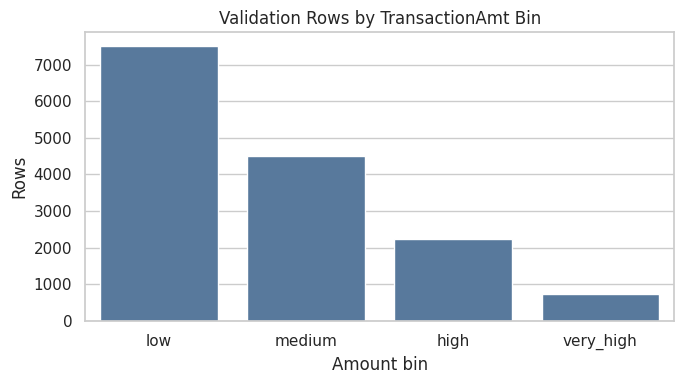

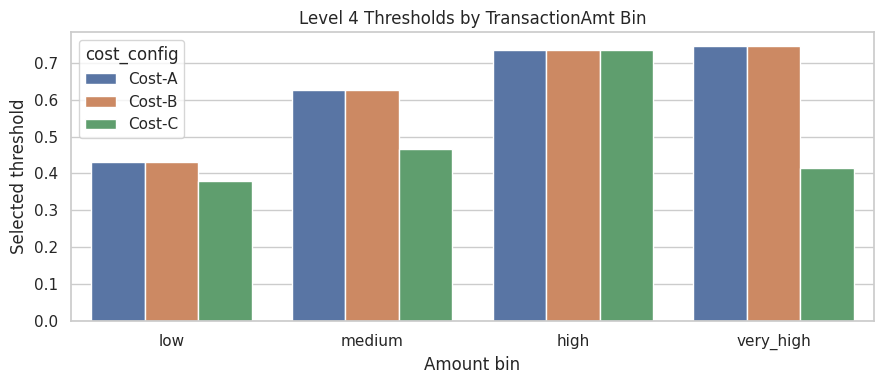

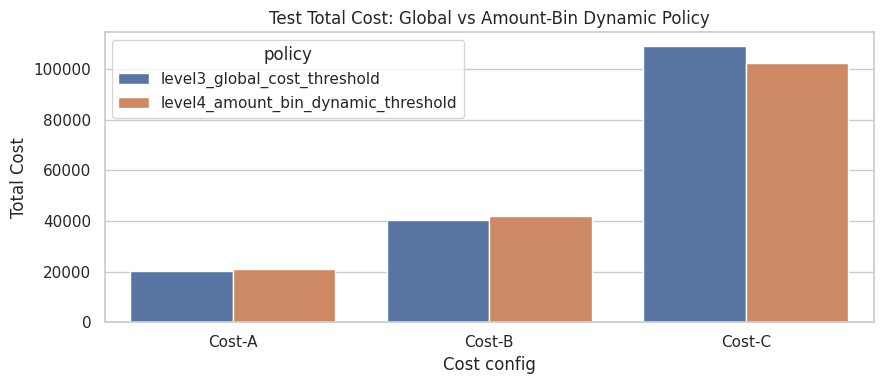

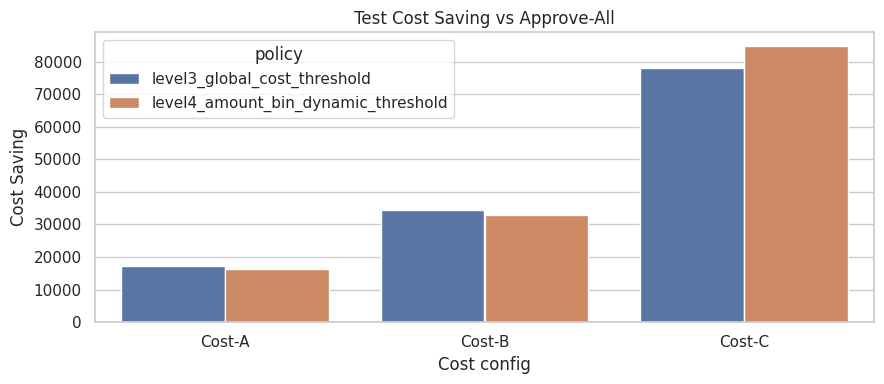

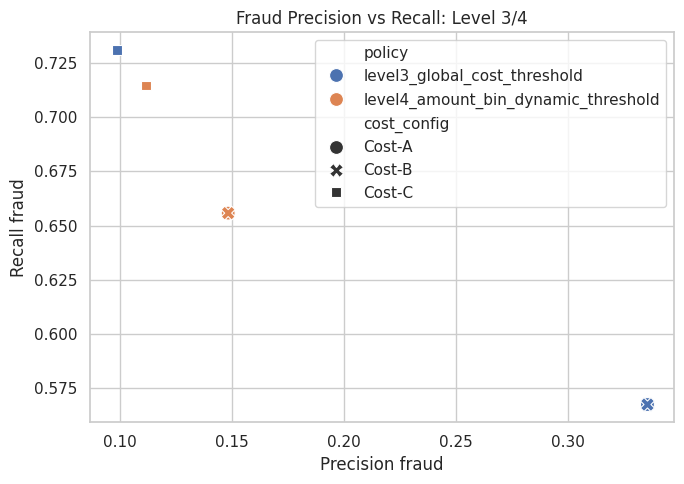

In [8]:
def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    plt.show()


plt.figure(figsize=(7, 4))
bin_counts = policy_scores[policy_scores["split"] == "validation"].groupby("amount_bin").size().reindex(amount_bin_labels)
sns.barplot(x=bin_counts.index, y=bin_counts.values, color="#4C78A8")
plt.title("Validation Rows by TransactionAmt Bin")
plt.xlabel("Amount bin")
plt.ylabel("Rows")
save_fig(FIGURES_DIR / f"phase31_amount_bins_{RUN_OUTPUT_TAG}.png")

plt.figure(figsize=(9, 4))
sns.barplot(data=level4_thresholds_df, x="amount_bin", y="threshold", hue="cost_config", order=amount_bin_labels)
plt.title("Level 4 Thresholds by TransactionAmt Bin")
plt.xlabel("Amount bin")
plt.ylabel("Selected threshold")
save_fig(FIGURES_DIR / f"phase31_thresholds_by_bin_{RUN_OUTPUT_TAG}.png")

test_dynamic = dynamic_policy_metrics_df[dynamic_policy_metrics_df["split"] == "test"].copy()
plt.figure(figsize=(9, 4))
sns.barplot(data=test_dynamic, x="cost_config", y="total_cost", hue="policy")
plt.title("Test Total Cost: Global vs Amount-Bin Dynamic Policy")
plt.xlabel("Cost config")
plt.ylabel("Total Cost")
save_fig(FIGURES_DIR / f"phase31_total_cost_{RUN_OUTPUT_TAG}.png")

plt.figure(figsize=(9, 4))
sns.barplot(data=test_dynamic, x="cost_config", y="cost_saving_vs_approve_all", hue="policy")
plt.title("Test Cost Saving vs Approve-All")
plt.xlabel("Cost config")
plt.ylabel("Cost Saving")
save_fig(FIGURES_DIR / f"phase31_cost_saving_{RUN_OUTPUT_TAG}.png")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=test_dynamic, x="precision_fraud", y="recall_fraud", hue="policy", style="cost_config", s=100)
plt.title("Fraud Precision vs Recall: Level 3/4")
plt.xlabel("Precision fraud")
plt.ylabel("Recall fraud")
save_fig(FIGURES_DIR / f"phase31_recall_precision_{RUN_OUTPUT_TAG}.png")


## 9. Metadata and Conclusion


In [9]:
phase31_run_metadata = {
    "phase": 3.1,
    "run_mode": RUN_MODE,
    "sample_rows": SAMPLE_ROWS_LABEL,
    "selected_risk_model": SELECTED_RISK_MODEL,
    "score_path": str(SCORE_PATH.relative_to(PROJECT_ROOT)),
    "baseline_metrics_path": str(BASELINE_METRICS_PATH.relative_to(PROJECT_ROOT)) if BASELINE_METRICS_PATH.exists() else None,
    "cost_configs": COST_CONFIGS,
    "amount_bin_quantiles": AMOUNT_BIN_QUANTILES,
    "amount_bin_labels": amount_bin_labels,
    "amount_bin_boundary_source": str(amount_bin_boundaries_df["boundary_source_split"].iloc[0]),
    "min_bin_validation_rows": MIN_BIN_VALIDATION_ROWS,
    "min_bin_validation_fraud": MIN_BIN_VALIDATION_FRAUD,
    "leakage_controls": {
        "threshold_tuning": "validation_only",
        "amount_bin_boundaries": "train_if_available_else_validation_amounts_without_test_labels",
        "test_usage": "report_only",
        "closed_form_dynamic_claim": "forbidden_transactionamt_cancels",
    },
    "outputs": {
        "dynamic_policy_metrics": str(DYNAMIC_METRICS_PATH.relative_to(PROJECT_ROOT)),
        "amount_bin_thresholds": str(AMOUNT_THRESHOLDS_PATH.relative_to(PROJECT_ROOT)),
        "amount_bin_boundaries": str(AMOUNT_BOUNDARIES_PATH.relative_to(PROJECT_ROOT)),
        "five_level_comparison": str((RESULTS_DIR / f"five_level_comparison_{RUN_OUTPUT_TAG}.csv").relative_to(PROJECT_ROOT)),
    },
}

for path in [RESULTS_DIR / "phase31_run_metadata.json", RESULTS_DIR / f"phase31_run_metadata_{RUN_OUTPUT_TAG}.json"]:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(phase31_run_metadata, f, ensure_ascii=False, indent=2)

best_dynamic = test_dynamic.sort_values(["cost_config", "total_cost"]).groupby("cost_config", as_index=False).first()
print("Best Level 3/4 policy by cost config")
display(best_dynamic[[
    "cost_config", "policy", "total_cost", "cost_saving_vs_approve_all",
    "recall_fraud", "precision_fraud", "f1_fraud", "pr_auc"
]])

print("Report notes:")
print("- Phase 3.1 implements Level 3 and Level 4 only; Level 5 is deferred to Phase 3.2.")
print("- Thresholds are tuned on validation only and then frozen for test evaluation.")
print("- The closed-form expected-cost threshold is not claimed as amount-dynamic because TransactionAmt cancels.")
print("- Level 4 is amount-aware because separate validation thresholds are tuned per frozen TransactionAmt bin.")
print("- If Level 4 does not beat Level 3, report it honestly and keep Q-bandit as ablation evidence.")


Best Level 3/4 policy by cost config


,cost_config,policy,total_cost,cost_saving_vs_approve_all,recall_fraud,precision_fraud,f1_fraud,pr_auc
0,Cost-A,level3_global_cost_threshold,20198.387418,17244.647541,0.567213,0.335271,0.421437,0.460326
1,Cost-B,level3_global_cost_threshold,40396.774837,34489.295082,0.567213,0.335271,0.421437,0.460326
2,Cost-C,level4_amount_bin_dynamic_threshold,102499.135839,84716.038958,0.714754,0.111623,0.193091,0.460326


Report notes:
- Phase 3.1 implements Level 3 and Level 4 only; Level 5 is deferred to Phase 3.2.
- Thresholds are tuned on validation only and then frozen for test evaluation.
- The closed-form expected-cost threshold is not claimed as amount-dynamic because TransactionAmt cancels.
- Level 4 is amount-aware because separate validation thresholds are tuned per frozen TransactionAmt bin.
- If Level 4 does not beat Level 3, report it honestly and keep Q-bandit as ablation evidence.
